In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

In [3]:
def q_racah_jacobi_matrix(N, q, alpha=1.0, beta=1.0, gamma=1.0, delta=1.0):
    """
    Build the (N+1)x(N+1) symmetric tridiagonal 'q-Racah Jacobi' matrix H(N,q;α,β,γ,δ).

        A_n^2 = ((1 - α q^{n+1})(1 - βδ q^{n+1})(1 - γ q^{n+1})(1 - δ q^{n+1}))
                /((1 - δ q^{2n+1})(1 - δ q^{2n+2})),      n = 0,...,N-1
        C_n^2 = ((1 -      q^n)(1 - β    q^n)(1 - γ    q^n)(1 - αδ q^n))
                /((1 - δ q^{2n  })(1 - δ q^{2n+1})),      n = 1,...,N

        B_n   = - (A_n^2 + C_n^2)
        H_nn      = A_n^2 + C_n^2
        H_n,n+1   = H_n+1,n = -A_n
        H_n,n-1   = H_n-1,n = -C_n
    """
    N = int(N)
    assert 0 < q < 1, "This toy is defined for 0<q<1 in the 'safe' regime."

    # n index 0,...,N
    n = np.arange(N + 1, dtype=float)

    # A_n for n=0,...,N-1
    nA = n[:-1]
    qn1 = q ** (nA + 1)
    numA = ((1 - alpha * qn1) *
            (1 - beta * delta * qn1) *
            (1 - gamma * qn1) *
            (1 - delta * qn1))
    denA = ((1 - delta * q ** (2 * nA + 1)) *
            (1 - delta * q ** (2 * nA + 2)))
    A2 = numA / denA

    # C_n for n=1,...,N
    nC = n[1:]
    qn = q ** nC
    numC = ((1 - qn) *
            (1 - beta * qn) *
            (1 - gamma * qn) *
            (1 - alpha * delta * qn))
    denC = ((1 - delta * q ** (2 * nC)) *
            (1 - delta * q ** (2 * nC + 1)))
    C2 = numC / denC

    # Numerical hygiene: kill tiny negative roundoff before sqrt
    def safe_sqrt(x):
        x = np.where(x < 0, np.where(x > -1e-14, 0.0, x), x)
        return np.sqrt(x)

    A = np.zeros(N + 1)
    C = np.zeros(N + 1)
    A[:-1] = safe_sqrt(A2)
    C[1:]  = safe_sqrt(C2)

    B = -(A**2 + C**2)

    # Build H
    H = np.zeros((N + 1, N + 1), dtype=float)
    # diagonal
    np.fill_diagonal(H, -B)           # = A^2 + C^2
    # super/sub diagonals
    for i in range(N):
        H[i, i+1] = H[i+1, i] = -A[i]
    for i in range(1, N+1):
        H[i, i-1] = H[i-1, i] = -C[i]

    return H

In [9]:
def doob_transform(H, tol=1e-12):
    """
    Given symmetric H, construct the continuous-time Markov generator Q
    via the ground-state Doob transform. Returns (Q, evals, psi0, ok, max_rowsum).
    """
    evals, evecs = np.linalg.eigh(H)
    idx = np.argsort(evals)
    evals = evals[idx]
    psi0  = np.abs(evecs[:, idx[0]])    # enforce nonnegativity

    if psi0.min() < tol:
        return None, evals, psi0, False, np.nan

    psi0 = psi0 / psi0.sum()

    # Off-diagonals Q_ij = -H_ij * psi0[j]/psi0[i]
    ratio = psi0[None, :] / psi0[:, None]
    Q = -H * ratio
    np.fill_diagonal(Q, 0.0)
    # Diagonal: holding rates
    np.fill_diagonal(Q, -Q.sum(axis=1))

    rowsum = Q.sum(axis=1)
    max_rowsum = float(np.max(np.abs(rowsum)))
    ok = max_rowsum < 1e-8

    return Q, evals, psi0, ok, max_rowsum


def spectral_gap(Q, tol=1e-10):
    """
    Return m_q(N) = smallest non-zero relaxation rate of e^{tQ}.
    Q has eigenvalues 0 = λ0 > λ1 ≥ ...; we return -λ1.
    """
    eig = np.linalg.eigvals(Q)
    eig = np.real_if_close(eig)
    eig = np.sort(eig)   # ascending: most negative ... up to ~0
    neg = eig[eig < -tol]
    return float(-neg[-1]) if neg.size else 0.0


def qracah_doob_gap(N, q, tol=1e-12, verbose=False):
    """
    Convenience wrapper: build H(N,q) with α=β=γ=δ=1,
    Doob-transform, and return (gap, ok, max_rowsum).
    """
    H = q_racah_jacobi_matrix(N, q, 1.0, 1.0, 1.0, 1.0)
    Q, evals, psi0, ok, max_rowsum = doob_transform(H, tol=tol)
    if not ok:
        if verbose:
            print(f"[WARN] Doob transform invalid: min(psi0)={psi0.min():.3e}, "
                  f"max|rowsum|={max_rowsum:.3e}")
        return np.nan, ok, max_rowsum
    gap = spectral_gap(Q, tol=tol)
    return gap, ok, max_rowsum

q=0.800  m_q(N=10) = 0.137868
q=0.821  m_q(N=10) = 0.131010
q=0.842  m_q(N=10) = 0.128273
q=0.863  m_q(N=10) = 0.128956
q=0.884  m_q(N=10) = 0.130301
q=0.906  m_q(N=10) = 0.128309
q=0.927  m_q(N=10) = 0.118991
q=0.948  m_q(N=10) = 0.099322
q=0.969  m_q(N=10) = 0.067743
q=0.990  m_q(N=10) = 0.024314


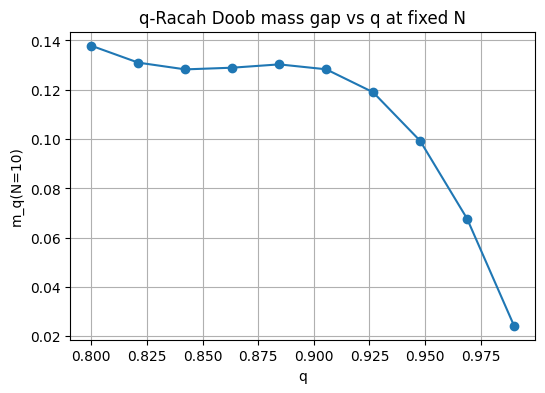

Fitted ν ≈ 0.903993


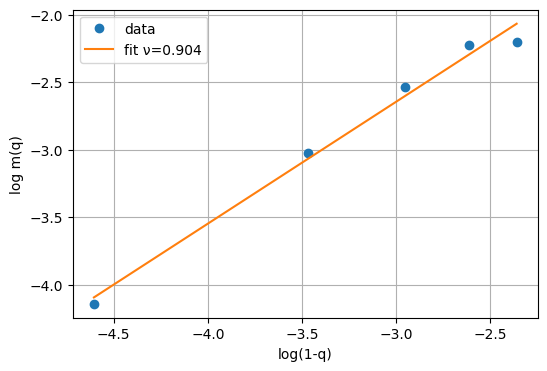

In [5]:
# 1) Basic sanity: gap vs q for a fixed, moderate N
N = 10
q_vals = np.linspace(0.80, 0.99, 10)
gaps_N = []

for q in q_vals:
    gap, ok, err = qracah_doob_gap(N, q)
    if not ok:
        print(f"q={q:.3f}: Doob invalid, rowsum error={err:.2e}")
    gaps_N.append(gap)
    print(f"q={q:.3f}  m_q(N={N}) = {gap:.6f}")

plt.figure(figsize=(6,4))
plt.plot(q_vals, gaps_N, 'o-')
plt.xlabel("q")
plt.ylabel(f"m_q(N={N})")
plt.title("q-Racah Doob mass gap vs q at fixed N")
plt.grid(True)
plt.show()


# 2) Finite-size scaling: m(q) = min_N m_q(N)

N_list   = [4, 6, 8, 10, 12]
q_values = np.linspace(0.80, 0.99, 10)

gaps = {}   # (N,q) -> gap
for N in N_list:
    for q in q_values:
        gap, ok, err = qracah_doob_gap(N, q)
        if not ok:
            print(f"[WARN] N={N}, q={q:.3f}: Doob invalid, rowsum={err:.2e}")
        gaps[(N,q)] = gap

# m(q) = min_N m_q(N)
m_q = []
for q in q_values:
    vals = [gaps[(N,q)] for N in N_list]
    m_q.append(min(vals))

# 3) Fit log m(q) vs log(1-q) near q=1

q_min = 0.90
qs_fit  = np.array([q for q in q_values if q >= q_min])
mq_fit  = np.array([m_q[q_values.tolist().index(q)] for q in qs_fit])

x = 1.0 - qs_fit
mask = x > 0
coef = np.polyfit(np.log(x[mask]), np.log(mq_fit[mask]), 1)
nu, logC = coef[0], coef[1]

print(f"Fitted ν ≈ {nu:.6f}")

# Optional: check fit visually
plt.figure(figsize=(6,4))
plt.plot(np.log(x[mask]), np.log(mq_fit[mask]), 'o', label="data")
plt.plot(np.log(x[mask]),
         nu*np.log(x[mask]) + logC,
         '-', label=f"fit ν={nu:.3f}")
plt.xlabel("log(1-q)")
plt.ylabel("log m(q)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def extrapolate_m_inf(q, Ns):
    """
    Given a list/array Ns and your function qracah_doob_gap(N, q),
    do a naive 1/N extrapolation: m(N) ≈ a + b/N.
    Returns (a, b, gaps).
    """
    # gaps_raw will be a list of tuples (gap_val, ok_bool, max_rowsum_val)
    gaps_raw = [qracah_doob_gap(N, q) for N in Ns]

    # Extract only the gap values (the first element of each tuple)
    # This ensures 'gaps' is a 1D array of numerical gap values, potentially including NaNs
    gaps = np.array([res[0] for res in gaps_raw])

    # Filter out NaNs for the least squares fit
    valid_mask = ~np.isnan(gaps)
    x_valid = (1.0 / Ns)[valid_mask]
    y_valid = gaps[valid_mask]

    # Need at least two valid data points to perform a linear fit
    if len(x_valid) < 2:
        return np.nan, np.nan, gaps # Return NaNs for a and b if not enough data

    A_valid = np.vstack([np.ones_like(x_valid), x_valid]).T
    a, b = np.linalg.lstsq(A_valid, y_valid, rcond=None)[0] # This now correctly returns two scalars

    return a, b, gaps

In [7]:
Ns = np.arange(10, 110, 10)  # 10,20,...,100
q_vals = np.linspace(0.80, 0.97, 18)

m_inf_vals = []
print("q_val | a (m_inf)       | b")
print("------------------------------------")
for q in q_vals:
    a, b, gaps = extrapolate_m_inf(q, Ns)
    m_inf_vals.append(a)
    print(f"{q:.3f}   | {a:<15.6f} | {b:.6f}")
m_inf_vals = np.array(m_inf_vals)


q_val | a (m_inf)       | b
------------------------------------
0.800   | 0.142677        | -0.044699
0.810   | 0.135113        | -0.009080
0.820   | 0.127099        | 0.038711
0.830   | 0.118608        | 0.099708
0.840   | 0.109645        | 0.173856
0.850   | 0.100257        | 0.259718
0.860   | 0.090533        | 0.354378
0.870   | 0.080601        | 0.453590
0.880   | 0.070617        | 0.552118
0.890   | 0.060756        | 0.644203
0.900   | 0.051230        | 0.724178
0.910   | 0.046252        | 0.735014
0.920   | 0.038411        | 0.778650
0.930   | 0.031602        | 0.805084
0.940   | 0.027921        | 0.779960
0.950   | 0.022941        | 0.758558
0.960   | 0.020354        | 0.687271
0.970   | 0.067084        | -0.013390


In [30]:
N_fixed = 10
q_vals  = np.linspace(0.80, 0.99, 10)

gaps = np.array([qracah_doob_gap(N_fixed, q) for q in q_vals])
x    = 1.0 - q_vals

# choose the few points near 1 with clean monotone decay
mask = (q_vals >= 0.90) & (q_vals <= 0.97)

logx = np.log(x[mask])
logm = np.log(gaps[mask])

slope, intercept = np.polyfit(logx, logm, 1)
nu_eff = -slope
print("Finite-N ν_eff ≈", nu_eff)


Finite-N ν_eff ≈ [-0.586443 -0.       -0.726465]


N_vals: [ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200]
q_vals[0], q_vals[-1]: 0.9 0.999
Computing gaps for N = 10 ...
Computing gaps for N = 20 ...
Computing gaps for N = 30 ...
Computing gaps for N = 40 ...
Computing gaps for N = 50 ...
Computing gaps for N = 60 ...
Computing gaps for N = 70 ...
Computing gaps for N = 80 ...
Computing gaps for N = 90 ...
Computing gaps for N = 100 ...
Computing gaps for N = 110 ...
Computing gaps for N = 120 ...
Computing gaps for N = 130 ...
Computing gaps for N = 140 ...
Computing gaps for N = 150 ...
Computing gaps for N = 160 ...
Computing gaps for N = 170 ...
Computing gaps for N = 180 ...
Computing gaps for N = 190 ...
Computing gaps for N = 200 ...
Saved grid to qracah_gap_grid.npz


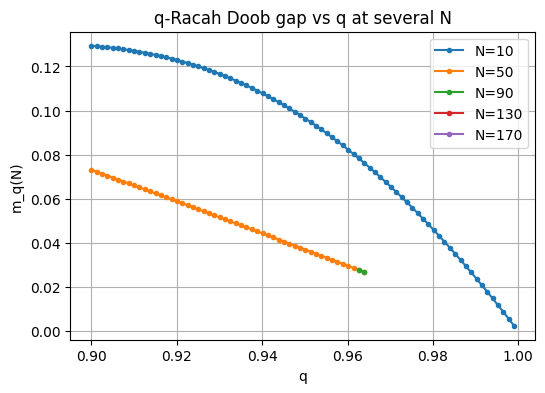

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG: make this as heavy as you like
# ----------------------------
N_min, N_max, N_step = 10, 200, 10    # sizes: 10,20,...,200
q_min, q_max = 0.90, 0.999            # approach q=1^- from below
n_q = 80                              # number of q points

N_vals = np.arange(N_min, N_max + 1, N_step)
q_vals = np.linspace(q_min, q_max, n_q)

print("N_vals:", N_vals)
print("q_vals[0], q_vals[-1]:", q_vals[0], q_vals[-1])

# gaps[N_index, q_index] = m_q(N, q)
gaps = np.zeros((len(N_vals), len(q_vals)), dtype=np.float64)

for i, N in enumerate(N_vals):
    print(f"Computing gaps for N = {N} ...")
    for j, q in enumerate(q_vals):
        gaps[i, j] = qracah_doob_gap(N, q)[0] # Extract only the gap value

# Save to disk so you don’t lose a long run
np.savez("qracah_gap_grid.npz", N_vals=N_vals, q_vals=q_vals, gaps=gaps)
print("Saved grid to qracah_gap_grid.npz")

# Quick sanity plot: m_q(N) vs q for a few sizes
plt.figure(figsize=(6,4))
for i, N in enumerate(N_vals[::max(1, len(N_vals)//5)]):
    plt.plot(q_vals, gaps[ i * (len(N_vals)//5), : ], marker='o', ms=3, label=f"N={N}")
plt.xlabel("q")
plt.ylabel("m_q(N)")
plt.title("q-Racah Doob gap vs q at several N")
plt.legend()
plt.grid(True)
plt.show()

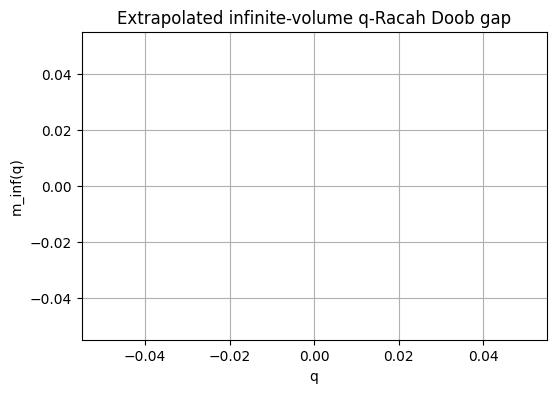

In [15]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("qracah_gap_grid.npz")
N_vals = data["N_vals"]
q_vals = data["q_vals"]
gaps   = data["gaps"]

# Removed the local definition of extrapolate_m_inf
# Now it will use the globally defined (and corrected) extrapolate_m_inf from cell FIEin3WxSxtJ

m_inf_vals = np.zeros_like(q_vals)
b_vals     = np.zeros_like(q_vals)

for j, q in enumerate(q_vals):
    # The global extrapolate_m_inf expects (q, Ns) and returns (a,b,gaps_list).
    # Here, we are providing N_vals and a column of gaps for a specific q.
    # So we call the global one with the correct signature and extract 'a'.
    a, b, _ = extrapolate_m_inf(q, N_vals) # Use the global extrapolate_m_inf
    m_inf_vals[j] = a
    b_vals[j]     = b

# Save extrapolated infinite-volume curve
np.savez("qracah_m_inf_vs_q.npz", q_vals=q_vals, m_inf=m_inf_vals, b_vals=b_vals)

# Plot m_inf(q)
plt.figure(figsize=(6,4))
plt.plot(q_vals, m_inf_vals, marker='o', ms=3)
plt.xlabel("q")
plt.ylabel("m_inf(q)")
plt.title("Extrapolated infinite-volume q-Racah Doob gap")
plt.grid(True)
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt

data_inf = np.load("qracah_m_inf_vs_q.npz")
q_vals   = data_inf["q_vals"]
m_inf    = data_inf["m_inf"]

# Distance to critical point q_c = 1 from below
x = 1.0 - q_vals

# Restrict to a small window near q=1 where scaling should hold
# tweak these bounds to taste
x_min, x_max = 1e-3, 5e-2
mask = (x > x_min) & (x < x_max) & (m_inf > 0)

x_fit   = x[mask]
m_fit   = m_inf[mask]

logx = np.log(x_fit)
logm = np.log(m_fit)

coef = np.polyfit(logx, logm, 1)   # log m ≈ c + ν_eff log(1-q)
slope, intercept = coef[0], coef[1]
nu_est = slope  # since log m ≈ ν log(1-q) + const, and log(1-q) < 0

print("Number of fit points:", len(x_fit))
print(f"Fitted ν ≈ {nu_est:.6f}")

# Plot the fit
plt.figure(figsize=(6,4))
plt.scatter(logx, logm, label="data")
plt.plot(logx, np.polyval(coef, logx), 'r-', label=f"fit ν≈{nu_est:.3f}")
plt.xlabel("log(1 - q)")
plt.ylabel("log m_inf(q)")
plt.title("q-Racah infinite-volume gap scaling")
plt.legend()
plt.grid(True)
plt.show()

TypeError: expected non-empty vector for x